# 1. Librerias

In [23]:
import os
import wfdb
import numpy as np

from sklearn.preprocessing import (
    StandardScaler
)

# 2. Rutas

In [24]:
AFDB_PATH = r'C:\Users\PC\Desktop\IA_AIFB\data\raw\AIFB'

QTDB_PATH = r'C:\Users\PC\Desktop\IA_AIFB\data\raw\QT'

# 3. Parámetros

In [25]:
FS = 250    # Frecuencia de Muestreo

WINDOW_SECONDS = 5  # Duración de la Ventana en Segundos

WINDOW_SIZE = FS * WINDOW_SECONDS   # Número de Muestras por Ventana

# 4. Función extractora

In [26]:
def extract_windows(
    path,
    label
):

    segments = []

    labels = []

    records = []

    for file in os.listdir(path):

        if file.endswith('.dat'):

            records.append(
                file.replace(
                    '.dat',
                    ''
                )
            )

    print(
        f'Total records: {len(records)}'
    )

    for record_name in records:

        print(
            f'Processing {record_name}'
        )

        record = wfdb.rdrecord(
            f'{path}/{record_name}'
        )

        signal = record.p_signal[:, 0]

        for i in range(
            0,
            len(signal) - WINDOW_SIZE,
            WINDOW_SIZE
        ):

            window = signal[
                i:i + WINDOW_SIZE
            ]

            segments.append(window)

            labels.append(label)

    return segments, labels

# 5. Extraer AFIB

In [27]:
afib_segments, afib_labels = (
    extract_windows(
        AFDB_PATH,
        1
    )
)

Total records: 23
Processing 04015
Processing 04043
Processing 04048
Processing 04126
Processing 04746
Processing 04908
Processing 04936
Processing 05091
Processing 05121
Processing 05261
Processing 06426
Processing 06453
Processing 06995
Processing 07162
Processing 07859
Processing 07879
Processing 07910
Processing 08215
Processing 08219
Processing 08378
Processing 08405
Processing 08434
Processing 08455


# 6. Extraer sanos

In [28]:
healthy_segments, healthy_labels = (
    extract_windows(
        QTDB_PATH,
        0
    )
)

Total records: 105
Processing sel100
Processing sel102
Processing sel103
Processing sel104
Processing sel114
Processing sel116
Processing sel117
Processing sel123
Processing sel14046
Processing sel14157
Processing sel14172
Processing sel15814
Processing sel16265
Processing sel16272
Processing sel16273
Processing sel16420
Processing sel16483
Processing sel16539
Processing sel16773
Processing sel16786
Processing sel16795
Processing sel17152
Processing sel17453
Processing sel213
Processing sel221
Processing sel223
Processing sel230
Processing sel231
Processing sel232
Processing sel233
Processing sel30
Processing sel301
Processing sel302
Processing sel306
Processing sel307
Processing sel308
Processing sel31
Processing sel310
Processing sel32
Processing sel33
Processing sel34
Processing sel35
Processing sel36
Processing sel37
Processing sel38
Processing sel39
Processing sel40
Processing sel41
Processing sel42
Processing sel43
Processing sel44
Processing sel45
Processing sel46
Processing sel

# 7. Unir datasets

In [29]:
X = np.array(
    healthy_segments +
    afib_segments
)

y = np.array(
    healthy_labels +
    afib_labels
)

print(X.shape)

print(y.shape)

(187462, 1250)
(187462,)


# 8. Balanceo

In [30]:
unique, counts = np.unique(
    y,
    return_counts=True
)

print(
    dict(zip(unique, counts))
)

{0: 18795, 1: 168667}


# 9. Normalización

In [31]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

# 10. Reshape CNN1D

In [32]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print(X.shape)

(187462, 1250, 1)


# 11. 

In [33]:
import os
import wfdb
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Configuración de rutas
AFDB_PATH = r'C:\Users\PC\Desktop\IA_AIFB\data\raw\AIFB'
QTDB_PATH = r'C:\Users\PC\Desktop\IA_AIFB\data\raw\QT'

FS = 250             # Frecuencia de Muestreo
WINDOW_SECONDS = 5   # Duración de la Ventana en Segundos
WINDOW_SIZE = FS * WINDOW_SECONDS   # Número de Muestras por Ventana (1250)

def extract_windows(path, label):
    segments = []
    labels = []
    records = []
    
    for file in os.listdir(path):
        if file.endswith('.dat'):
            records.append(file.replace('.dat', ''))
            
    print(f'Total records in {path}: {len(records)}')
    
    for record_name in records:
        print(f'Processing {record_name}')
        record = wfdb.rdrecord(f'{path}/{record_name}')
        signal = record.p_signal[:, 0]
        
        for i in range(0, len(signal) - WINDOW_SIZE, WINDOW_SIZE):
            window = signal[i:i + WINDOW_SIZE]
            segments.append(window)
            labels.append(label)
            
    return segments, labels

# Extraer ventanas de ambas bases de datos
afib_segments, afib_labels = extract_windows(AFDB_PATH, 1)
healthy_segments, healthy_labels = extract_windows(QTDB_PATH, 0)

# Convertir a arreglos de NumPy
afib_segments = np.array(afib_segments)
afib_labels = np.array(afib_labels)
healthy_segments = np.array(healthy_segments)
healthy_labels = np.array(healthy_labels)

# Balancear las clases mediante Downsampling aleatorio
min_samples = healthy_segments.shape[0]
np.random.seed(42) 
random_indices = np.random.choice(afib_segments.shape[0], size=min_samples, replace=False)
afib_segments_balanced = afib_segments[random_indices]
afib_labels_balanced = afib_labels[random_indices]

# Combinar conjuntos de datos balanceados
X = np.concatenate((healthy_segments, afib_segments_balanced), axis=0)
y = np.concatenate((healthy_labels, afib_labels_balanced), axis=0)

# Escalamiento y Normalización
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape para formato CNN1D (Muestras, Longitud, Canales)
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"\nMatriz X global balanceada: {X.shape}")

# =============================================================================
# NUEVA SECCIÓN: DIVISIÓN EN ENTREMANIENTO Y PRUEBA (TRAIN / TEST SPLIT)
# =============================================================================
# Dividimos el 80% para entrenar la red y el 20% para evaluar qué tan buena es.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n--- Partición de Datos Completada ---")
print(f"X_train (Entrenamiento): {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test (Prueba/Validación): {X_test.shape} | y_test: {y_test.shape}")

# Verificamos que se mantenga el equilibrio 50/50 en el set de entrenamiento
unique_train, counts_train = np.unique(y_train, return_counts=True)
print(f"Distribución en entrenamiento: {dict(zip(unique_train, counts_train))}")

Total records in C:\Users\PC\Desktop\IA_AIFB\data\raw\AIFB: 23
Processing 04015
Processing 04043
Processing 04048
Processing 04126
Processing 04746
Processing 04908
Processing 04936
Processing 05091
Processing 05121
Processing 05261
Processing 06426
Processing 06453
Processing 06995
Processing 07162
Processing 07859
Processing 07879
Processing 07910
Processing 08215
Processing 08219
Processing 08378
Processing 08405
Processing 08434
Processing 08455
Total records in C:\Users\PC\Desktop\IA_AIFB\data\raw\QT: 105
Processing sel100
Processing sel102
Processing sel103
Processing sel104
Processing sel114
Processing sel116
Processing sel117
Processing sel123
Processing sel14046
Processing sel14157
Processing sel14172
Processing sel15814
Processing sel16265
Processing sel16272
Processing sel16273
Processing sel16420
Processing sel16483
Processing sel16539
Processing sel16773
Processing sel16786
Processing sel16795
Processing sel17152
Processing sel17453
Processing sel213
Processing sel221
Proc

In [34]:
import os
import wfdb
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Importamos las librerías de Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

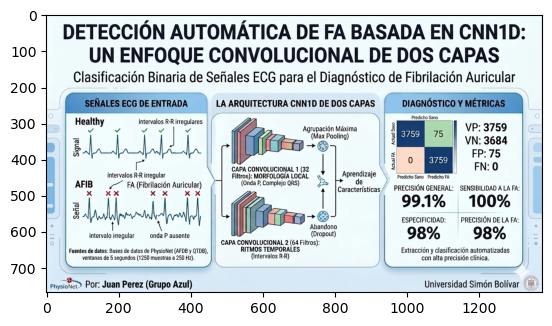

In [42]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread(r'C:\Users\PC\Desktop\IA_AIFB\models\ejemplo.png')
plt.imshow(img);

In [35]:
# Inicializamos el modelo secuencial ajustado a ESTRICTAMENTE 2 CAPAS CONVOLUCIONALES
model = Sequential([
    # Capa Convolucional 1: Extracción de morfología base (picos y ondas iniciales)
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(WINDOW_SIZE, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    
    # Capa Convolucional 2: Combinación temporal (detección del ritmo regular/irregular)
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    
    # Bloque de Clasificación (Transición de mapas de características a decisión)
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    
    # Capa de Salida: Clasificación Binaria (Sano vs AFIB)
    Dense(1, activation='sigmoid')
])

# Desplegamos la estructura del modelo modificado
model.summary()

# %% [markdown]
# ### Celda 2: Compilación del Modelo

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("¡Modelo de 2 capas compilado exitosamente!")

# %% [markdown]
# ### Celda 3: Entrenamiento y Evaluación del Modelo

print("\n--- Iniciando el entrenamiento de la CNN1D (2 Capas) ---")
history = model.fit(
    X_train, y_train,
    epochs=10,               
    batch_size=64,           
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluar el rendimiento final en los datos de prueba
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n=========================================================")
print(f"Resultados finales del modelo (2 Capas) en el set de prueba:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy * 100:.2f}%")
print(f"=========================================================")

# %% [markdown]
# ### Celda 4: Guardado del Modelo Modificado

MODEL_DIR = r'C:\Users\PC\Desktop\IA_AIFB\models'
os.makedirs(MODEL_DIR, exist_ok=True)
model_path = os.path.join(MODEL_DIR, 'cnn1d_afib_detector.keras')

model.save(model_path)
print(f"\n[ÉXITO] ¡Modelo de 2 capas guardado correctamente en: {model_path}!")


c:\Users\PC\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 1246, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 623, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 623, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 619, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 309, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 309, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 19776)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,265,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,289 (4.87 MB)

 Trainable params: 1,276,289 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

¡Modelo de 2 capas compilado exitosamente!

--- Iniciando el entrenamiento de la CNN1D (2 Capas) ---
Epoch 1/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 54s 106ms/step - accuracy: 0.8049 - loss: 0.4139 - val_accuracy: 0.8692 - val_loss: 0.3265
Epoch 2/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.8979 - loss: 0.2576 - val_accuracy: 0.8976 - val_loss: 0.2432
Epoch 3/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 74s 157ms/step - accuracy: 0.9312 - loss: 0.1873 - val_accuracy: 0.9420 - val_loss: 0.1540
Epoch 4/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 85s 181ms/step - accuracy: 0.9457 - loss: 0.1529 - val_accuracy: 0.9294 - val_loss: 0.1760
Epoch 5/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 39s 82ms/step - accuracy: 0.9578 - loss: 0.1199 - val_accuracy: 0.9553 - val_loss: 0.1069
Epoch 6/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - accuracy: 0.9672 - loss: 0.0959 - val_accuracy: 0.9810 - val_loss: 0.0543
Epoch 7/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9751 - loss: 0.0777 - val_accuracy: 0.9842 - v

In [36]:
MODEL_DIR = r'C:\Users\PC\Desktop\IA_AIFB\models'
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, 'cnn1d_afib_detector.keras')

# Guardamos el modelo completo
model.save(model_path)
print(f"\n[ÉXITO] ¡Modelo entrenado guardado correctamente en: {model_path}!")


[ÉXITO] ¡Modelo entrenado guardado correctamente en: C:\Users\PC\Desktop\IA_AIFB\models\cnn1d_afib_detector.keras!


In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


--- Calculando Predicciones del Conjunto de Prueba ---



Reporte de Clasificación Extendido:
              precision    recall  f1-score   support

    Sano (0)       1.00      0.98      0.99      3759
    AFIB (1)       0.98      1.00      0.99      3759

    accuracy                           0.99      7518
   macro avg       0.99      0.99      0.99      7518
weighted avg       0.99      0.99      0.99      7518



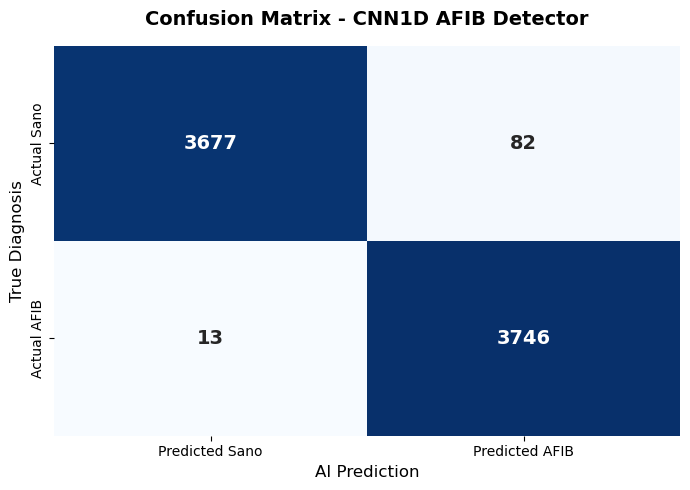

In [ ]:
print("\n--- Calculando Predicciones del Conjunto de Prueba ---")
# 1. Obtener las probabilidades (valores entre 0 y 1 de la capa Sigmoide)
y_pred_probs = model.predict(X_test, verbose=0)

# 2. Convertir probabilidades a clases binarias (Umbral estándar del 50%)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 3. Calcular la matriz de confusión matemática
cm = confusion_matrix(y_test, y_pred)

# 4. Imprimir reporte de clasificación en texto detallando precisión por clase
print("\nReporte de Clasificación Extendido:")
print(classification_report(y_test, y_pred, target_names=['Sano (0)', 'AFIB (1)']))

# 5. Graficar la Matriz de Confusión Visual de forma profesional
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Predicted Sano', 'Predicted AFIB'], 
    yticklabels=['Actual Sano', 'Actual AFIB'],
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title('Confusion Matrix - CNN1D AFIB Detector', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Diagnosis', fontsize=12)
plt.xlabel('AI Prediction', fontsize=12)
plt.tight_layout()

# Guardamos la imagen
OUTPUT_DIR = r'C:\Users\PC\Desktop\IA_AIFB\models'
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=300)
plt.show() # Muestra la gráfica en tu consola interactiva de VS Code
plt.close()